In [ ]:
import torch

print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("cleaned_data.csv",encoding="ISO-8859-1")
df.head()

,Unnamed: 0,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment,clean_text
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral,drinking today worldcup
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive,amazing worldcup launch video show much face c...
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive,worth reading watching worldcup
3,3,2022-11-20 23:58:33+00:00,1,Twitter Web App,Golden Maknae shinning bright\n\nhttps://t.co/...,positive,golden maknae shinning bright jeonjungkook jun...
4,4,2022-11-20 23:58:28+00:00,0,Twitter for Android,"If the BBC cares so much about human rights, h...",negative,bbc care much human right homosexual right wom...


In [ ]:
texts = df["clean_text"].astype(str)

labels = df["Sentiment"]

# LABEL ENCODING
label_encoder = LabelEncoder()

labels_encoded = label_encoder.fit_transform(labels)

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": list(y_train)
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": list(y_test)
})

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=4,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=100,

    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy
    }

In [ ]:
torch.cuda.empty_cache()
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.545644,0.570322
2,0.445689,0.560869
3,0.331806,0.636468
4,0.245345,0.690407


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4508, training_loss=0.42749486174748447, metrics={'train_runtime': 286.6197, 'train_samples_per_second': 251.469, 'train_steps_per_second': 15.728, 'total_flos': 1622395455301224.0, 'train_loss': 0.42749486174748447, 'epoch': 4.0})

In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

print(
    classification_report(
        y_test,
        preds,
        target_names=label_encoder.classes_
    )
)

accuracy = accuracy_score(
    y_test,
    preds
)

print("DistilBERT Accuracy:", accuracy)

              precision    recall  f1-score   support

    negative       0.78      0.79      0.78      1157
     neutral       0.73      0.73      0.73      1650
    positive       0.81      0.81      0.81      1698

    accuracy                           0.77      4505
   macro avg       0.77      0.77      0.77      4505
weighted avg       0.77      0.77      0.77      4505

DistilBERT Accuracy: 0.7733629300776914


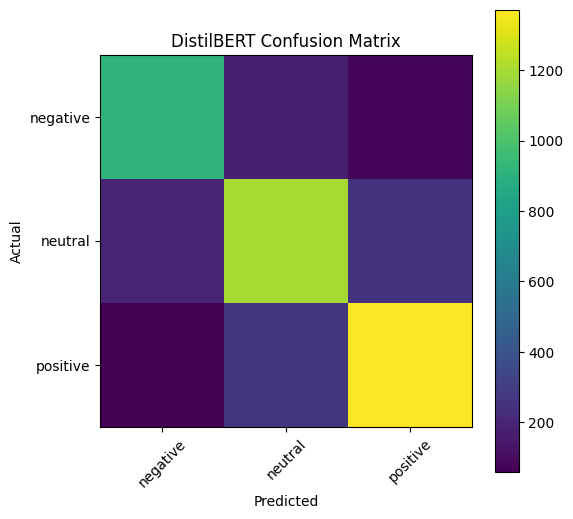

In [ ]:
cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("DistilBERT Confusion Matrix")

plt.colorbar()

plt.xticks(
    range(3),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(3),
    label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
model.save_pretrained("distilbert_model")

tokenizer.save_pretrained("distilbert_model")

print("DistilBERT Model Saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT Model Saved


In [ ]:
results = pd.DataFrame({
    "Model": ["DistilBERT"],
    "Accuracy": [accuracy]
})

results.to_csv(
    "distilbert_results.csv",
    index=False
)

print(results)

        Model  Accuracy
0  DistilBERT  0.773363
